<a href="https://colab.research.google.com/github/xr-cc/DSCoV-Workshop-on-Topic-Modeling/blob/main/topic_modeling_scRNAseq_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic Modeling Demo 2 (scRNA-seq)
In this notebook, we will see how topic modeling methods LDA and NMF can be applied onto a real-word single-cell RNA sequencing (scRNA-seq) dataset.

The dataset is downloaded from [PBMC from a healthy donor - granulocytes removed through cell sorting (10k)](https://support.10xgenomics.com/single-cell-multiome-atac-gex/datasets/1.0.0/pbmc_granulocyte_sorted_10k) from 10x Genomics, which contains cryopreserved human peripheral blood mononuclear cells (**PBMCs**) of a healthy female donor aged 25.

> The data file stores gene expression counts per cell after quality filtering has been applied. Each value in the matrix is the number of unique RNA molecules (UMIs) detected for a given gene in a given cell.

The Python package `Scanpy` will be used to load and process the data.

**Reference**

10x Genomics. 2020. PBMC from a healthy donor – granulocytes removed through cell sorting (10k); Single Cell Multiome ATAC + Gene Expression (Cell Ranger ARC v1.0.0) [Data set]. 10x Genomics.


Install package `scanpy` for single cell data processing.

In [2]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.3/169.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 6.8 MB/s eta 0:00:00


Import packages

In [42]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors

import scanpy as sc
from sklearn.decomposition import LatentDirichletAllocation, NMF

from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load data

In [16]:
# Load the HDF5 file from Google Drive
file_path = '/content/drive/MyDrive/DSCoV_Workshop/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5' # Update the path if needed

adata = sc.read_10x_h5(file_path)
adata

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 11909 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [21]:
# Filter out low-quality genes and cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata)

# Select highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')
adata = adata[:, adata.var.highly_variable]

adata

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


View of AnnData object with n_obs × n_vars = 11852 × 3000
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [26]:
# Extract data matrix
X = adata.X
print(X.shape)

df = pd.DataFrame(
    adata.X.toarray(),        # convert sparse to dense
    index=adata.obs_names,    # cells
    columns=adata.var_names   # genes
)

(11852, 3000)


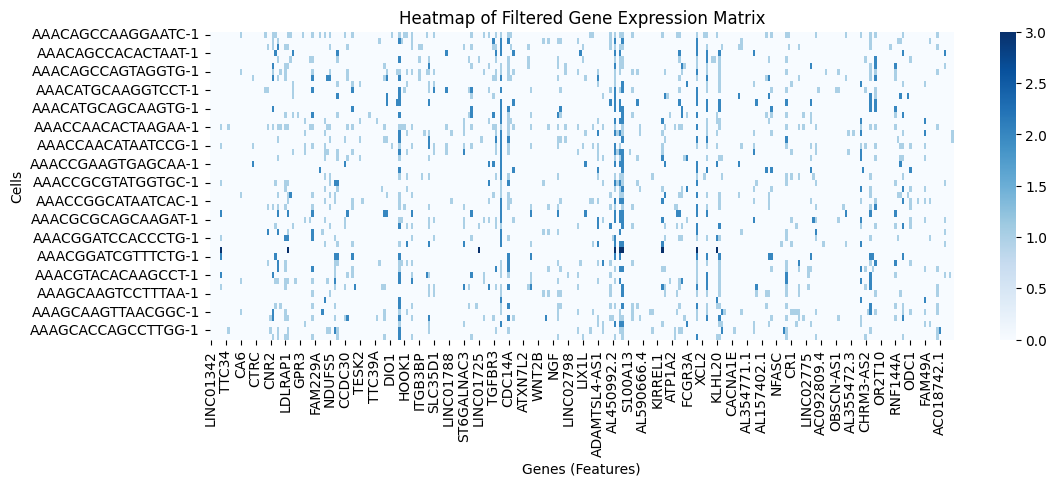

In [25]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.iloc[0:50][df.columns[:300]].astype(int), cmap='Blues') # You can choose a different colormap
plt.title('Heatmap of Filtered Gene Expression Matrix')
plt.xlabel('Genes (Features)')
plt.ylabel('Cells')
plt.show()

## Perform dimensionality reduction to visualize cells

In [28]:
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


## Perform topic modeling via LDA

In [ ]:
# Define the number of latent cell types
n_topics = 5

# Create an LDA model
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)

# Fit the model to the filtered gene expression matrix
lda.fit(X)

# Get the cell-type distribution for each cell
Phi = lda.transform(X)

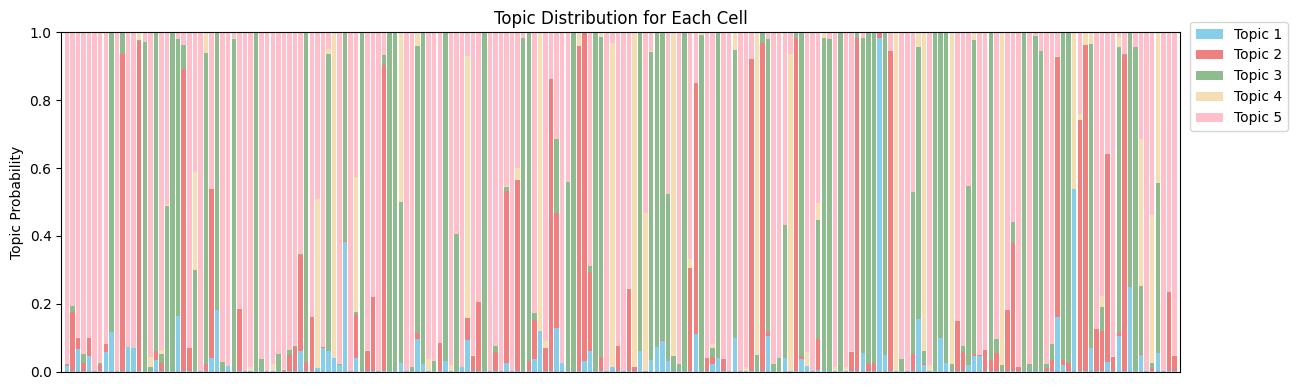

In [34]:
# Define colors for each topic
colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat', 'pink', 'orange', 'brown', 'purple', 'gray', 'olive']

# Plot the stacked bar charts for document-topic vectors for first 1000 cells
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 4)) # Adjust figure size as needed
for i in range(200):
    topic_probabilities = Phi[i]
    bottom = 0
    for topic_idx, prob in enumerate(topic_probabilities):
        ax.bar(i, prob, bottom=bottom, color=colors[topic_idx % len(colors)], label=f'Topic {topic_idx+1}' if i == 0 else "") # Add label only for the first bar
        bottom += prob

ax.set_xticks([])
ax.set_xlim(-1, 200)
ax.set_ylabel('Topic Probability')
ax.set_ylim(0, 1)
ax.set_title('Topic Distribution for Each Cell')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[:n_topics], labels[:n_topics], loc='upper left', bbox_to_anchor=(0.99, 0.95))
plt.tight_layout()
plt.show()

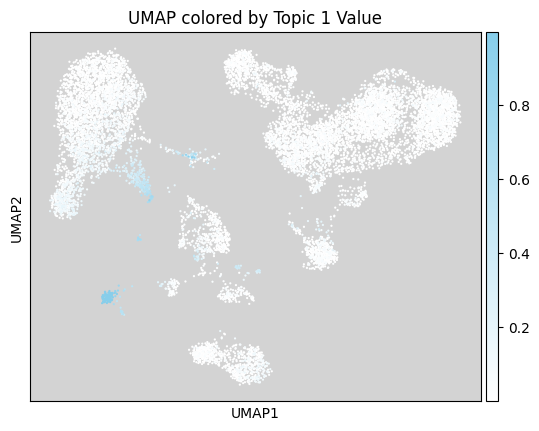

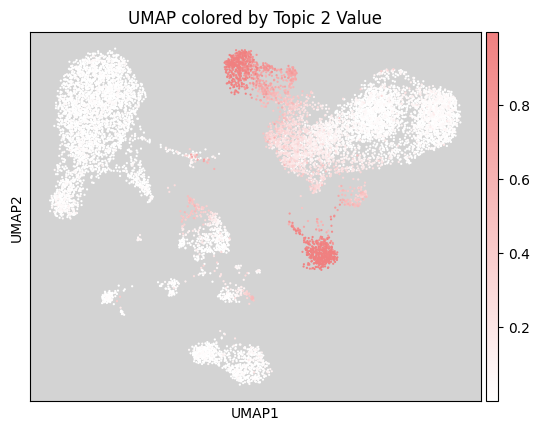

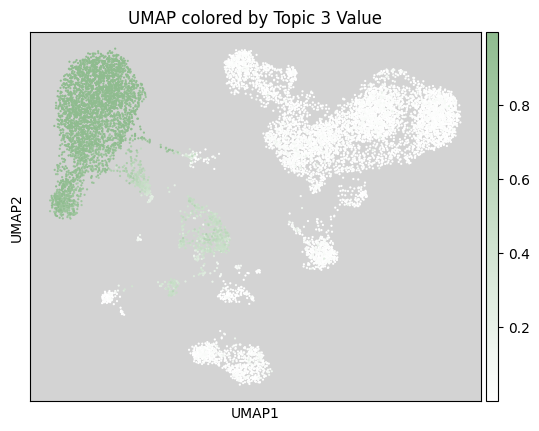

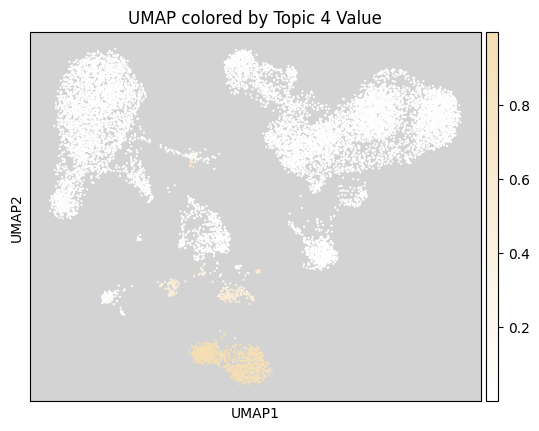

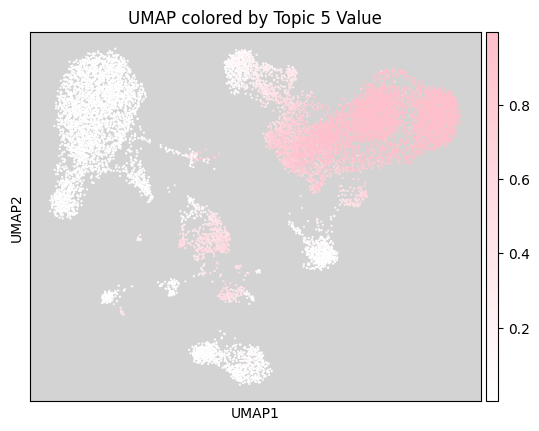

In [44]:
# Define the base colors for each topic
base_colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat', 'pink']

for topic_idx in range(n_topics):
  # Add per-topic values to adata.obs
  adata.obs['topic_{}_value'.format(topic_idx+1)] = Phi[:, topic_idx]

  # Create a gradient colormap for the current topic
  base_color = base_colors[topic_idx % len(base_colors)]
  colors = [(1, 1, 1), matplotlib.colors.to_rgb(base_color)] # White to base color
  cmap = matplotlib.colors.LinearSegmentedColormap.from_list("white_to_{}".format(base_color), colors)

  # Plot cells in UMAP space colored by the per-topic value
  sc.pl.umap(adata, color='topic_{}_value'.format(topic_idx+1), title='UMAP colored by Topic {} Value'.format(topic_idx+1), cmap=cmap, show=False)
  plt.gca().set_facecolor('lightgray')
  plt.show()